# All-Angle Routing

All-angle routing lets you connect ports along an **arbitrary backbone** — segments do
not have to be axis-aligned.  Unlike manhattan routing (which forces horizontal/vertical
segments), all-angle routes follow any sequence of `kdb.DPoint` waypoints and insert
euler bends at each corner.

| Feature | API |
|---|---|
| Single route | `kf.routing.aa.optical.route(c, width, backbone, ...)` |
| Bundle of routes | `kf.routing.aa.optical.route_bundle(c, start_ports, end_ports, backbone, ...)` |
| Result object | `OpticalAllAngleRoute` — `.length`, `.backbone`, `.instances` |

## When to use all-angle routing

* Diagonal bus sections in large photonic chips
* Routing around non-rectilinear obstacles
* Compact fan-outs at arbitrary angles

## Setup

All-angle routing uses **virtual factories** from `kf.factories.virtual.*`.  Virtual
components live in memory only and are materialised into a real cell when
`VInstance.insert_into(c)` is called (or when routing directly into a `KCell`).

In [1]:
from functools import partial

import numpy as np

import kfactory as kf


class LAYER(kf.LayerInfos):
    WG: kf.kdb.LayerInfo = kf.kdb.LayerInfo(1, 0)
    WGCLAD: kf.kdb.LayerInfo = kf.kdb.LayerInfo(2, 0)


L = LAYER()
kf.kcl.infos = L

wg_enc = kf.LayerEnclosure(name="WGSTD_AA", sections=[(L.WGCLAD, 0, 2_000)])

# Virtual straight: width and length in µm
straight_factory = partial(
    kf.factories.virtual.straight.virtual_straight_factory(kcl=kf.kcl),
    layer=L.WG,
    enclosure=wg_enc,
)

# Virtual euler bend: width and radius in µm
bend_factory = partial(
    kf.factories.virtual.euler.virtual_bend_euler_factory(kcl=kf.kcl),
    width=0.5,
    radius=10,
    layer=L.WG,
    enclosure=wg_enc,
)

## 1 · Single all-angle route

`kf.routing.aa.optical.route` places a single route along a **backbone** — an ordered
list of `kdb.DPoint` values in µm.  The router inserts euler bends wherever the
backbone changes direction and fills the straight segments automatically.

Rules for a valid backbone:

* At least 3 points (the first and last define the port orientations)
* Each interior segment must be long enough to fit the bend: roughly
  `2 × effective_radius` clearance on either side of a corner

The returned `OpticalAllAngleRoute` exposes:

* `.length` — total path length in µm
* `.length_straights` — straight-only contribution in µm
* `.backbone` — the original backbone points
* `.instances` — list of placed `VInstance` objects

Total length : 320.00 µm
Straight length: 245.20 µm
Bend count     : 74.80 µm in bends


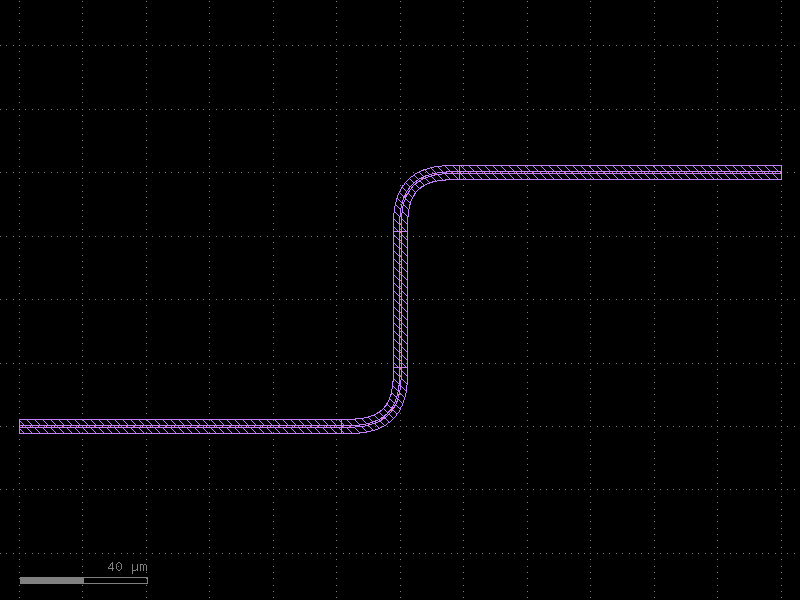

In [2]:
backbone_single = [
    kf.kdb.DPoint(0, 0),
    kf.kdb.DPoint(120, 0),  # horizontal run
    kf.kdb.DPoint(120, 80),  # 90° turn upward
    kf.kdb.DPoint(240, 80),  # horizontal run to exit
]

c_single = kf.kcl.kcell("aa_single_route")
route = kf.routing.aa.optical.route(
    c_single,
    width=0.5,
    backbone=backbone_single,
    straight_factory=straight_factory,
    bend_factory=bend_factory,
)

print(f"Total length : {route.length:.2f} µm")
print(f"Straight length: {route.length_straights:.2f} µm")
print(f"Bend count     : {route.length - route.length_straights:.2f} µm in bends")

c_single.plot()

## 2 · Diagonal backbone

The backbone is not restricted to axis-aligned segments.  Diagonal segments route
through tight corridors where a manhattan route would require many detours.

Total length: 320.00 µm


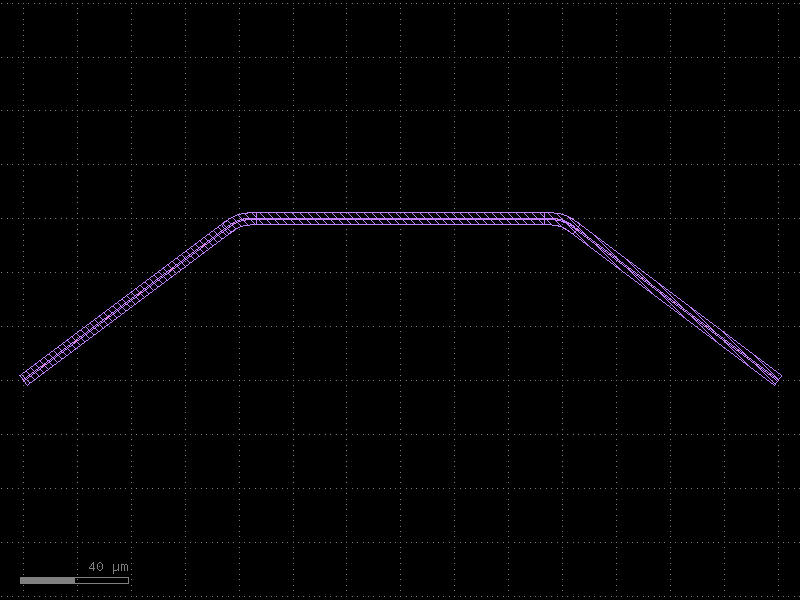

In [3]:
backbone_diag = [
    kf.kdb.DPoint(0, 0),
    kf.kdb.DPoint(80, 60),  # diagonal up-right
    kf.kdb.DPoint(200, 60),  # horizontal
    kf.kdb.DPoint(280, 0),  # diagonal back down
]

c_diag = kf.kcl.kcell("aa_diagonal_route")
route_diag = kf.routing.aa.optical.route(
    c_diag,
    width=0.5,
    backbone=backbone_diag,
    straight_factory=straight_factory,
    bend_factory=bend_factory,
)

print(f"Total length: {route_diag.length:.2f} µm")
c_diag.plot()

## 3 · Bundle routing

`kf.routing.aa.optical.route_bundle` routes **multiple ports in parallel** along a
shared backbone.  Each route in the bundle is offset from the backbone by `separation`
(or a per-route list).

**Port orientation convention**

* `start_ports` — sorted **anti-clockwise** around the start cluster
* `end_ports` — sorted **clockwise** around the end cluster

This ensures that routes do not cross between the start cluster and the backbone.

**Backbone requirements for bundles**

The backbone must have at least 2 points (it defines the shared bundle axis).  Segments
must be long enough to accommodate the widest route in the bundle plus its separation.

Bundle contains 5 routes
  route 0: length = 2965.36 µm
  route 1: length = 3040.05 µm
  route 2: length = 3182.96 µm
  route 3: length = 3471.07 µm
  route 4: length = 3876.84 µm


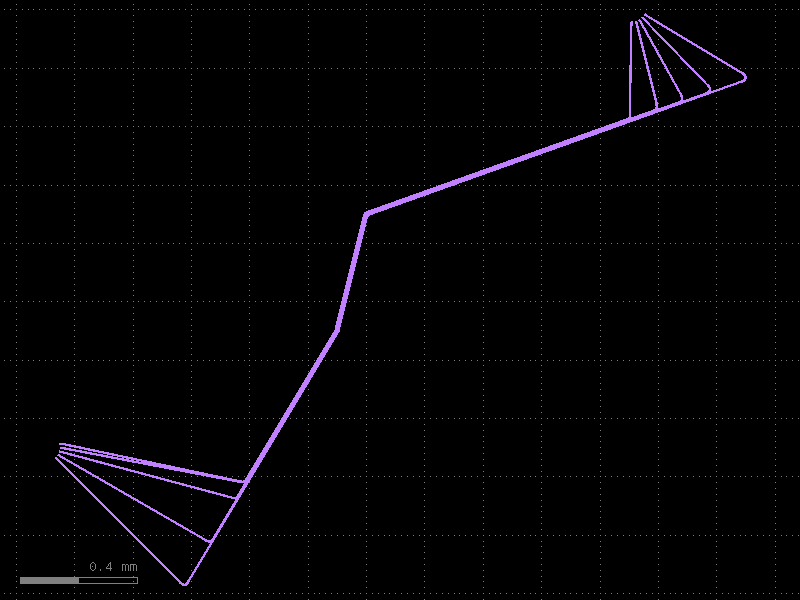

In [4]:
# Place start ports fanned out at various angles on the left, end ports on the right
r = 50  # radius of port fan-out cluster (µm)
n = 1  # angle step centre
_l = 5  # number of routes

c_bundle = kf.kcl.kcell("aa_bundle_route")

start_ports: list[kf.Port] = []
end_ports: list[kf.Port] = []

for i in range(_l):
    a_start = (n - i) * 15  # angles spread around centre
    a_rad = np.deg2rad(a_start)
    a_end = 270 - n + i * 15
    ae_rad = np.deg2rad(a_end)

    start_ports.append(
        c_bundle.create_port(
            name=f"s{i}",
            dcplx_trans=kf.kdb.DCplxTrans(
                1,
                a_start,
                False,
                -500 + r * np.cos(a_rad),
                -100 + r * np.sin(a_rad),
            ),
            layer=c_bundle.kcl.find_layer(L.WG),
            width=c_bundle.kcl.to_dbu(0.5),
        )
    )
    end_ports.append(
        c_bundle.create_port(
            name=f"e{i}",
            dcplx_trans=kf.kdb.DCplxTrans(
                1,
                a_end,
                False,
                1510 + r * np.cos(ae_rad),
                1410 + r * np.sin(ae_rad),
            ),
            layer=c_bundle.kcl.find_layer(L.WG),
            width=c_bundle.kcl.to_dbu(0.5),
        )
    )

# Shared backbone — each segment long enough for 10 µm-radius euler bends
backbone_bundle = [
    kf.kdb.DPoint(200, -200),
    kf.kdb.DPoint(500, 300),
    kf.kdb.DPoint(600, 700),
    kf.kdb.DPoint(1300, 950),
]

routes = kf.routing.aa.optical.route_bundle(
    c_bundle,
    start_ports=start_ports,
    end_ports=end_ports,
    backbone=backbone_bundle,
    separation=2.0,  # µm between adjacent routes
    straight_factory=straight_factory,
    bend_factory=bend_factory,
)

print(f"Bundle contains {len(routes)} routes")
for i, rt in enumerate(routes):
    print(f"  route {i}: length = {rt.length:.2f} µm")

c_bundle.plot()

## 4 · Using VKCell for preview before committing

All-angle routing can also target a `VKCell` (virtual cell) so you can inspect or
transform the result before materialising it into a real cell with
`VInstance.insert_into`.

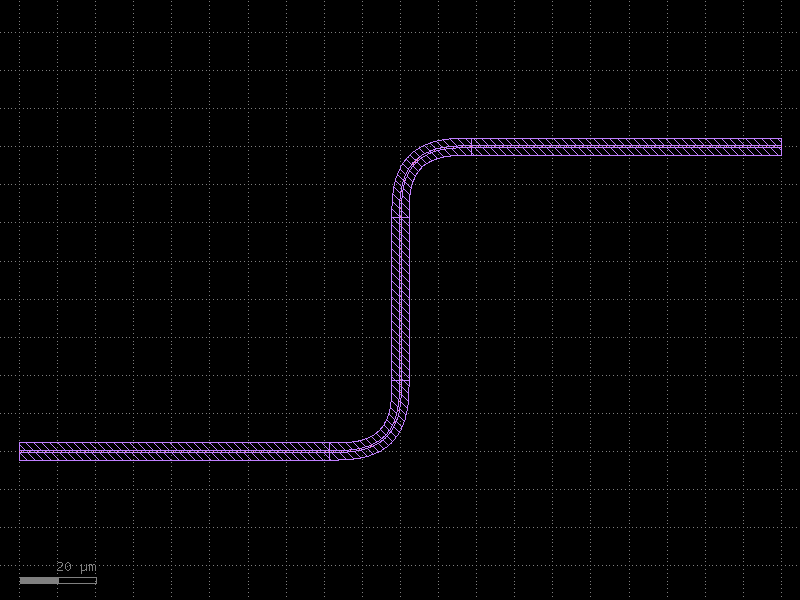

In [5]:
vc = kf.kcl.vkcell(name="aa_virtual")
kf.routing.aa.optical.route(
    vc,
    width=0.5,
    backbone=[
        kf.kdb.DPoint(0, 0),
        kf.kdb.DPoint(100, 0),
        kf.kdb.DPoint(100, 80),
        kf.kdb.DPoint(200, 80),
    ],
    straight_factory=straight_factory,
    bend_factory=bend_factory,
)

# Materialise: place the virtual route into a real KCell
c_real = kf.kcl.kcell("aa_from_virtual")
vi = kf.VInstance(vc)
vi.insert_into(c_real)
c_real.plot()

## Summary

| Parameter | Type | Unit | Notes |
|---|---|---|---|
| `backbone` | `list[kdb.DPoint]` | µm | ≥3 points for single route, ≥2 for bundle |
| `width` | `float` | µm | route width (single route only) |
| `separation` | `float` or `list[float]` | µm | spacing between bundle routes |
| `straight_factory` | callable | — | `virtual_straight_factory` partial |
| `bend_factory` | callable | — | `virtual_bend_euler_factory` partial |

**Key constraints**

* Each backbone segment must be long enough to fit the euler bends on both ends
  (~2 × effective radius per corner).
* For bundles, segments must also accommodate the full bundle width
  (`N × (wire_width + separation)`).
* `start_ports` must be sorted anti-clockwise; `end_ports` clockwise.

## See Also

| Topic | Where |
|-------|-------|
| Manhattan (90°/180° bend) routing | [Routing: Optical](optical.py) |
| Virtual cells used as intermediate routing containers | [Components: Virtual Cells](../components/cells/virtual.py) |
| Euler bend cells and `virtual_bend_euler_factory` | [Components: Euler Bends](../components/cells/factories/euler.py) |
| Routing overview and choosing an approach | [Routing: Overview](overview.py) |
| Port construction and `DCplxTrans` | [Core Concepts: Ports](../concepts/ports.py) |